# Three-stage active-learning comparison

This notebook separates three questions that must not be conflated:

1. **Does the implemented active-learning loop work mechanically on a learnable three-class problem?**
2. **Does the same loop improve label efficiency on the real LaSDPC T+RH observations with the project's noisy synthetic oracle?**
3. **Does the same loop improve label efficiency on the real Bath T+RH observations with the project's Bath-specific synthetic oracle?**

The first stage is a software sanity benchmark, not evidence about occupants or a heritage building. The second and third stages use the committed experiment CSVs so this notebook does not rerun the expensive real-data experiments. Balanced accuracy and macro-F1 are included because raw accuracy can reward majority-class prediction.

> Synthetic labels validate mechanics under stated assumptions; they do not validate real-occupant comfort prediction.

### Code explanation: prepare the three-stage comparison

**Purpose.** Load the statistical, plotting and active-learning modules and locate the preserved real-data experiment outputs.

**What the code does.**

1. Imports pandas, NumPy, Matplotlib and SciPy statistics.
2. Imports the production synthetic-label generator, schema, evaluation helpers and active-learning loop.
3. Sets table and plot formatting.
4. Builds paths to the frozen Bath and LaSDPC run CSVs and fails if either is unavailable.

**Why this code is included.** The notebook reruns only the lightweight controlled benchmark and reads the expensive real-data experiments from their preserved outputs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from dissertation_code import config
from dissertation_code.comfort import synthetic_labels as sl
from dissertation_code.data import schema
from dissertation_code.evaluation import analysis
from dissertation_code.model import active_learning as al

pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-whitegrid')

BATH_RUNS_PATH = config.RESULTS_DIR / 'experiment_runs.csv'
LASDPC_RUNS_PATH = config.RESULTS_DIR / 'lasdpc_runs.csv'
assert BATH_RUNS_PATH.exists(), BATH_RUNS_PATH
assert LASDPC_RUNS_PATH.exists(), LASDPC_RUNS_PATH
print('Bath results:  ', BATH_RUNS_PATH)
print('LaSDPC results:', LASDPC_RUNS_PATH)

Bath results:   /home/sai/Desktop/projects/srinidhi_project/dissertation_code/evaluation/results/experiment_runs.csv
LaSDPC results: /home/sai/Desktop/projects/srinidhi_project/dissertation_code/evaluation/results/lasdpc_runs.csv


#### Output explanation

**What the output is.** The output prints the resolved Bath and LaSDPC result-file paths without raising an assertion error.

**What the output means.** Both frozen experiment exports are available, so later comparisons use the measured ten-seed results rather than silently rerunning or substituting them.

**Important interpretation boundary.** Finding the files verifies provenance and availability, not the correctness of their metrics; schema and matched-seed checks follow later.

## Stage 1 — controlled three-class mechanics benchmark

A seeded T+RH grid deliberately spans cold, neutral and warm PMV regions. Labels are generated by the repository's existing PMV label generator with `noise_sigma=0` and `merge_warm=False`. This creates a deterministic target whose boundary is learnable from the two permitted features.

Both random and entropy strategies use the production `ComfortModel` and `run_active_learning` implementation. Domain triggers are disabled so this stage isolates uncertainty sampling. The benchmark is fixed in advance: 2,500 pool rows, 2,500 independent test rows, seeds 42–51, 30 initial labels and a 250-label budget.

### Code explanation: construct an independent learnable three-class control

**Purpose.** Create a controlled T+RH problem that tests whether the active-learning implementation can work when class boundaries are clear and deterministic.

**What the code does.**

1. Draws temperature uniformly from 12 to 36 degrees C and RH from 35% to 85% using a fixed random seed.
2. Creates separate 2,500-row pool and test frames with different seeds and non-overlapping dates.
3. Uses the production label generator with zero noise and without merging the warm class.
4. Displays the class shares in both independent frames.

**Why this code is included.** This positive control separates software capability from the harder question of whether the current noisy real-data targets are learnable.

In [2]:
def make_controlled_frame(n_rows, seed, start):
    rng = np.random.default_rng(seed)
    frame = pd.DataFrame(
        {
            schema.TIMESTAMP: pd.date_range(start, periods=n_rows, freq='5min'),
            schema.ZONE: 'controlled',
            schema.TEMPERATURE: rng.uniform(12.0, 36.0, n_rows),
            schema.RELATIVE_HUMIDITY: rng.uniform(35.0, 85.0, n_rows),
        }
    )
    return sl.generate_labels(
        frame,
        sl.GeneratorConfig(noise_sigma=0.0, merge_warm=False),
    )

controlled_pool = make_controlled_frame(2_500, seed=123, start='2024-01-01')
controlled_test = make_controlled_frame(2_500, seed=456, start='2025-01-01')

controlled_description = pd.DataFrame(
    {
        'pool share': controlled_pool[sl.COMFORT_CLASS].value_counts(normalize=True),
        'test share': controlled_test[sl.COMFORT_CLASS].value_counts(normalize=True),
    }
).fillna(0.0)
controlled_description

,pool share,test share
comfort_class,,
comfortable,0.4104,0.3948
too_cool,0.3248,0.3136
too_warm,0.2648,0.2916


#### Output explanation

**What the output is.** The table shows all three comfort classes in both frames: approximately 39-41% comfortable, 31-32% too cool and 26-29% too warm.

**What the output means.** The controlled pool and test set contain substantial support for every class, so balanced accuracy can test a genuine three-class boundary. Similar but non-identical shares are expected from independent seeded samples.

**Important interpretation boundary.** This is a deliberately controlled benchmark, not simulated evidence that Bath experienced the same environmental range.

### Code explanation: run the controlled active-learning experiment

**Purpose.** Compare random and entropy selection using the production loop across ten matched seeds.

**What the code does.**

1. Runs each query strategy for seeds 42 through 51.
2. Starts with 30 labels, requests batches of 10 and stops at 250 labels.
3. Disables the domain trigger so the benchmark isolates query-strategy behaviour.
4. Stores accuracy, balanced accuracy and macro-F1 at every label checkpoint.

**Why this code is included.** A repeated matched-seed design reveals whether any observed entropy advantage is consistent rather than a favourable single seed.

In [3]:
controlled_rows = []
for strategy in ('random', 'entropy'):
    for seed in range(42, 52):
        result = al.run_active_learning(
            controlled_pool,
            controlled_test,
            seed_count=30,
            batch_size=10,
            max_labels=250,
            random_state=seed,
            strategy=strategy,
            use_trigger=False,
        )
        controlled_rows.extend(
            {
                'stage': 'Controlled three-class',
                'strategy': strategy,
                'seed': seed,
                'n_labels': n_labels,
                'accuracy': accuracy,
                'balanced_accuracy': balanced_accuracy,
                'macro_f1': macro_f1,
            }
            for n_labels, accuracy, balanced_accuracy, macro_f1 in zip(
                result.label_counts,
                result.accuracies,
                result.balanced_accuracies,
                result.macro_f1s,
            )
        )
controlled_runs = pd.DataFrame(controlled_rows)
print(f'Controlled experiment rows: {len(controlled_runs):,}')

Controlled experiment rows: 460


#### Output explanation

**What the output is.** The output reports 460 controlled experiment rows: 23 label checkpoints for each of 20 strategy-seed runs.

**What the output means.** The expected number of records confirms complete coverage of two strategies, ten seeds and the full 30-to-250 label budget. These rows form the learning curves and paired final comparisons used below.

**Important interpretation boundary.** A complete result table does not itself establish superiority; the effect size, confidence interval and paired test must be examined.

## Stages 2 and 3 — load the committed real-data experiments

The LaSDPC and Bath experiments already took tens of minutes to run and are seeded. Their per-iteration outputs are loaded directly. This preserves the original evidence rather than generating a new result during presentation.

### Code explanation: load and validate the real-data experiment exports

**Purpose.** Bring the previously completed LaSDPC and Bath runs into the same schema as the controlled stage.

**What the code does.**

1. Reads the two saved CSV files and adds a stage name.
2. Checks that strategy, seed, label budget and all three metrics are present.
3. Prints the number of seeds, label range and strategies for each dataset.

**Why this code is included.** Structural validation prevents an invalid comparison caused by missing metrics, unmatched arms or incomplete exports.

In [4]:
lasdpc_runs = pd.read_csv(LASDPC_RUNS_PATH).assign(stage='LaSDPC')
bath_runs = pd.read_csv(BATH_RUNS_PATH).assign(stage='Bath')

required = {'strategy', 'seed', 'n_labels', 'accuracy', 'balanced_accuracy', 'macro_f1'}
for name, frame in [('LaSDPC', lasdpc_runs), ('Bath', bath_runs)]:
    missing = required - set(frame.columns)
    assert not missing, f'{name} results missing {missing}'
    print(
        f'{name}: {frame.seed.nunique()} seeds, '
        f'{int(frame.n_labels.min())}-{int(frame.n_labels.max())} labels, '
        f"strategies={sorted(frame.strategy.unique())}"
    )

LaSDPC: 10 seeds, 20-400 labels, strategies=['entropy', 'random']
Bath: 10 seeds, 20-2000 labels, strategies=['entropy', 'random']


#### Output explanation

**What the output is.** LaSDPC contains 10 seeds from 20 to 400 labels and Bath contains 10 seeds from 20 to 2,000 labels; both contain entropy and random strategies.

**What the output means.** Each real-data stage has the required repeated two-arm design. Bath uses a larger label budget because its pool is much larger; comparisons are made within each stage, not by comparing raw budget sizes across datasets.

**Important interpretation boundary.** This cell loads frozen outputs and does not rerun either expensive real-data experiment.

## Matched-seed comparison

Random and entropy runs use the same seed values. The statistical unit is therefore the within-seed difference, so a paired t-test and paired-difference confidence interval are reported. The table includes all three metrics to expose majority-class effects.

### Code explanation: calculate matched final-budget comparisons

**Purpose.** Measure strategy differences fairly by pairing entropy and random results from the same seed.

**What the code does.**

1. Selects the largest label budget for each stage.
2. Pivots results so entropy and random from each seed form one matched pair.
3. Calculates the mean paired difference, a t-based 95% confidence interval and paired t-test p-value.
4. Counts entropy wins and repeats the calculation for accuracy, balanced accuracy and macro-F1.

**Why this code is included.** Pairing removes between-seed noise from the strategy contrast, while multiple metrics reveal class-imbalance artefacts.

In [5]:
def paired_final_comparison(runs, stage, metric):
    final_budget = int(runs['n_labels'].max())
    final = runs.loc[runs['n_labels'].eq(final_budget)]
    paired = final.pivot(index='seed', columns='strategy', values=metric).dropna()
    if not {'random', 'entropy'} <= set(paired.columns):
        raise ValueError(f'{stage} lacks matched random and entropy rows')
    difference = paired['entropy'] - paired['random']
    standard_error = stats.sem(difference)
    if len(difference) > 1 and standard_error > 0:
        half_width = stats.t.ppf(0.975, len(difference) - 1) * standard_error
    else:
        half_width = 0.0
    return {
        'stage': stage,
        'metric': metric,
        'labels': final_budget,
        'random mean': paired['random'].mean(),
        'entropy mean': paired['entropy'].mean(),
        'entropy - random': difference.mean(),
        'paired 95% CI low': difference.mean() - half_width,
        'paired 95% CI high': difference.mean() + half_width,
        'paired p-value': stats.ttest_rel(paired['entropy'], paired['random']).pvalue,
        'entropy wins': int((difference > 0).sum()),
        'matched seeds': len(difference),
    }

stage_runs = {
    'Controlled three-class': controlled_runs,
    'LaSDPC': lasdpc_runs,
    'Bath': bath_runs,
}
comparison = pd.DataFrame(
    [
        paired_final_comparison(runs, stage, metric)
        for stage, runs in stage_runs.items()
        for metric in ('accuracy', 'balanced_accuracy', 'macro_f1')
    ]
)
comparison

,stage,metric,labels,random mean,entropy mean,entropy - random,paired 95% CI low,paired 95% CI high,paired p-value,entropy wins,matched seeds
0,Controlled three-class,accuracy,250,0.9816,0.9922,0.0106,0.0074,0.0138,4.1080e-05,10,10
1,Controlled three-class,balanced_accuracy,250,0.9826,0.9925,0.0099,0.0074,0.0125,1.0928e-05,10,10
2,Controlled three-class,macro_f1,250,0.9820,0.9924,0.0104,0.0072,0.0136,4.2970e-05,10,10
3,LaSDPC,accuracy,400,0.7167,0.7356,0.0189,-0.0026,0.0404,7.7855e-02,7,10
4,LaSDPC,balanced_accuracy,400,0.5801,0.5782,-0.0019,-0.0239,0.0201,8.5047e-01,5,10
5,LaSDPC,macro_f1,400,0.5676,0.5704,0.0027,-0.0228,0.0282,8.1459e-01,6,10
6,Bath,accuracy,2000,0.5594,0.5564,-0.0029,-0.0365,0.0307,8.4828e-01,9,10
7,Bath,balanced_accuracy,2000,0.5087,0.5043,-0.0044,-0.0089,0.0002,5.6745e-02,2,10
8,Bath,macro_f1,2000,0.4696,0.4129,-0.0567,-0.0809,-0.0325,4.8763e-04,0,10


#### Output explanation

**What the output is.** The nine-row table reports three metrics for each stage. Controlled entropy improves balanced accuracy by 0.0099 with confidence interval 0.0074 to 0.0125, p=0.0000109 and 10/10 wins. LaSDPC balanced difference is -0.0019 with p=0.8505. Bath balanced difference is -0.0044 with p=0.0567, while Bath macro-F1 is lower by 0.0567 with p=0.00049.

**What the output means.** Entropy has a small but consistent controlled advantage. Neither real-data stage shows a positive balanced-accuracy advantage. LaSDPC's positive raw-accuracy difference has a paired confidence interval crossing zero, so it cannot override the balanced result. Bath macro-F1 indicates worse minority-class performance under entropy.

**Important interpretation boundary.** A p-value is not the practical effect size, and failing to reject zero is not proof that both strategies are identical. The defensible claim is that an advantage was not demonstrated under this design.

## Label efficiency on the primary metric

For each stage, label efficiency asks how many labels entropy needs to reach random sampling's final **balanced accuracy**. `Not reached` is an experimental result, not a missing value or software error.

### Code explanation: measure label efficiency

**Purpose.** Ask how many labels each strategy needs to reach the final balanced accuracy achieved by its random baseline.

**What the code does.**

1. Uses the project evaluation helper to define each stage's target as random's final mean balanced accuracy.
2. Finds the earliest label checkpoint at which each strategy reaches that target.
3. Calculates the active strategy's label saving when a target is reached.
4. Displays `Not reached` instead of inventing a saving when entropy never reaches the target.

**Why this code is included.** Sample efficiency is the main reason to use active learning, so final accuracy alone is insufficient.

In [6]:
efficiency_rows = []
for stage, runs in stage_runs.items():
    efficiency = analysis.label_efficiency(runs, metric='balanced_accuracy')
    for _, row in efficiency.iterrows():
        efficiency_rows.append(
            {
                'stage': stage,
                'strategy': row['strategy'],
                'random final balanced accuracy': row['target_metric'],
                'labels to target': (
                    int(row['labels_to_target'])
                    if pd.notna(row['labels_to_target'])
                    else 'Not reached'
                ),
                'label saving': row.get('label_saving', np.nan),
            }
        )
efficiency_table = pd.DataFrame(efficiency_rows)
efficiency_table

,stage,strategy,random final balanced accuracy,labels to target,label saving
0,Controlled three-class,entropy,0.9826,120,0.52
1,Controlled three-class,random,0.9826,250,0.00
2,LaSDPC,entropy,0.5801,Not reached,NaN
3,LaSDPC,random,0.5801,220,0.00
4,Bath,entropy,0.5087,Not reached,NaN
5,Bath,random,0.5087,1950,0.00


#### Output explanation

**What the output is.** Controlled entropy reaches the target at 120 labels versus 250 for random, a 0.52 or 52% saving. LaSDPC and Bath entropy are `Not reached`; the random curves first reach their own final mean targets at 220 and 1,950 labels, respectively.

**What the output means.** The controlled stage demonstrates a real label-efficiency benefit. The real-data stages provide no supported entropy saving under balanced accuracy, so reporting a percentage saving for them would be misleading.

**Important interpretation boundary.** `Not reached` is a result, not missing data. It means the active curve did not meet the specified random target within the measured budget.

### Code explanation: plot the three balanced-accuracy learning curves

**Purpose.** Show how performance and between-seed uncertainty change across the full label budget rather than only at the final checkpoint.

**What the code does.**

1. Aggregates each stage by strategy and label count using the shared learning-curve helper.
2. Plots mean balanced accuracy for entropy and random.
3. Adds the calculated confidence bands around each mean curve.
4. Places the controlled, LaSDPC and Bath panels side by side on the same conceptual comparison.

**Why this code is included.** Curve shape can reveal early label savings, convergence, overlap and instability that one final score hides.

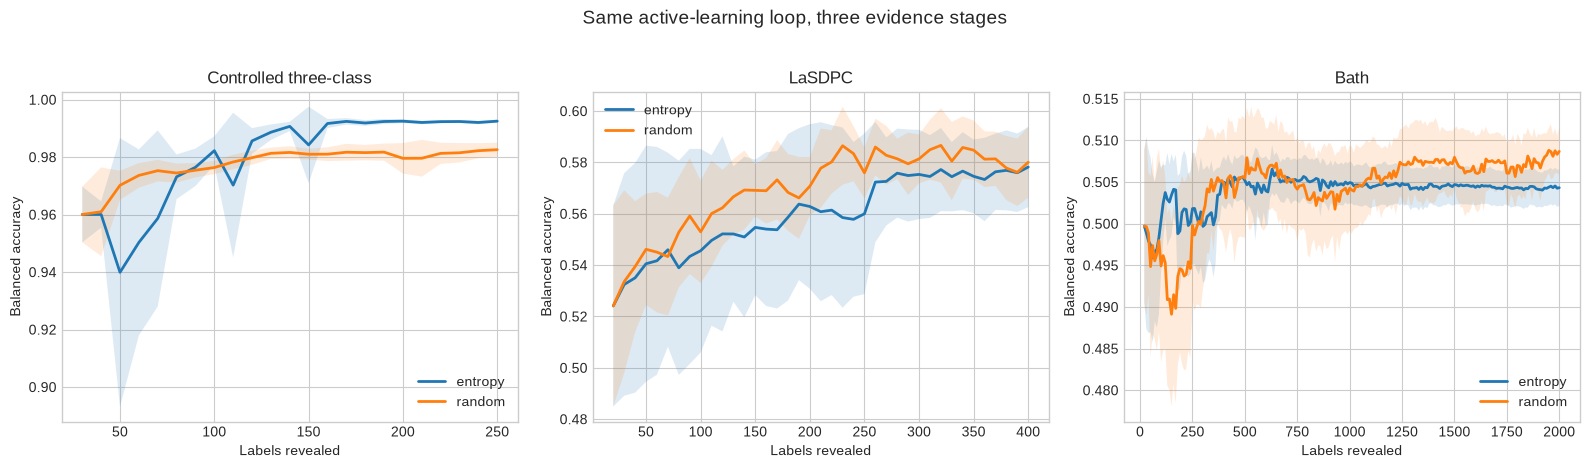

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (stage, runs) in zip(axes, stage_runs.items()):
    curve = analysis.learning_curve(runs, metric='balanced_accuracy')
    for strategy, group in curve.groupby('strategy'):
        group = group.sort_values('n_labels')
        ax.plot(group['n_labels'], group['mean'], label=strategy, linewidth=2)
        ax.fill_between(
            group['n_labels'], group['ci_lower'], group['ci_upper'], alpha=0.15
        )
    ax.set(title=stage, xlabel='Labels revealed', ylabel='Balanced accuracy')
    ax.legend()
plt.suptitle('Same active-learning loop, three evidence stages', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

#### Output explanation

**What the output is.** A three-panel figure shows balanced accuracy against labels for the controlled, LaSDPC and Bath stages, with separate random and entropy lines and uncertainty bands.

**What the output means.** The controlled entropy curve separates from random and reaches strong performance earlier. The real-data curves do not show a stable positive entropy separation; their overlap and variability agree with the matched final-budget tests.

**Important interpretation boundary.** The bands summarise repeated seeds at each checkpoint. They do not represent uncertainty about all possible buildings, occupants or synthetic-oracle choices.

## Final three-stage result

The summary below deliberately avoids treating raw-accuracy improvement as sufficient evidence. A successful stage requires a positive balanced-accuracy difference whose paired confidence interval excludes zero, plus earlier attainment of random's final balanced accuracy.

### Code explanation: assemble the headline three-stage result

**Purpose.** Condense the primary balanced-accuracy evidence into one supervisor-facing table.

**What the code does.**

1. Selects balanced-accuracy rows from the full metric comparison.
2. Selects entropy label-efficiency rows.
3. Combines target construction, paired difference, p-value, labels to target and a bounded interpretation for each stage.

**Why this code is included.** The project needs one clear distinction between mechanical capability and transfer to the two noisy real-data cases.

In [8]:
balanced = comparison.loc[comparison['metric'].eq('balanced_accuracy')].set_index('stage')
entropy_efficiency = efficiency_table.loc[
    efficiency_table['strategy'].eq('entropy')
].set_index('stage')

three_stage_summary = pd.DataFrame(
    {
        'target': [
            'Deterministic PMV, 3 classes',
            'PMV + N(0,1), 3 classes',
            'Adaptive-clo PMV + N(0,1), 2 observed classes',
        ],
        'entropy - random balanced accuracy': [
            balanced.loc['Controlled three-class', 'entropy - random'],
            balanced.loc['LaSDPC', 'entropy - random'],
            balanced.loc['Bath', 'entropy - random'],
        ],
        'paired p-value': [
            balanced.loc['Controlled three-class', 'paired p-value'],
            balanced.loc['LaSDPC', 'paired p-value'],
            balanced.loc['Bath', 'paired p-value'],
        ],
        'entropy labels to random target': [
            entropy_efficiency.loc['Controlled three-class', 'labels to target'],
            entropy_efficiency.loc['LaSDPC', 'labels to target'],
            entropy_efficiency.loc['Bath', 'labels to target'],
        ],
        'interpretation': [
            'Loop mechanics succeed on a learnable three-class boundary',
            'No balanced-accuracy advantage over random',
            'No balanced-accuracy advantage over random',
        ],
    },
    index=['Controlled three-class', 'LaSDPC', 'Bath'],
)
three_stage_summary

,target,entropy - random balanced accuracy,paired p-value,entropy labels to random target,interpretation
Controlled three-class,"Deterministic PMV, 3 classes",0.0099,1.0928e-05,120,Loop mechanics succeed on a learnable three-cl...
LaSDPC,"PMV + N(0,1), 3 classes",-0.0019,8.5047e-01,Not reached,No balanced-accuracy advantage over random
Bath,"Adaptive-clo PMV + N(0,1), 2 observed classes",-0.0044,5.6745e-02,Not reached,No balanced-accuracy advantage over random


#### Output explanation

**What the output is.** The table states: controlled deterministic three-class entropy difference +0.0099 and target reached at 120 labels; LaSDPC difference -0.0019 and not reached; Bath difference -0.0044 and not reached.

**What the output means.** The active-learning loop succeeds when the three-class boundary is learnable, but the benefit does not transfer under either current noisy real-data target. This is the primary class-balanced conclusion for the dissertation.

**Important interpretation boundary.** The controlled result validates mechanics only. It must not be reported as evidence of Bath or real-occupant accuracy.

### Code explanation: verify the final interpretation programmatically

**Purpose.** Bind the notebook's written conclusion to explicit conditions that must remain true.

**What the code does.**

1. Checks that the controlled target contains three classes.
2. Checks that controlled entropy improves balanced accuracy, has a confidence interval above zero and reaches the target earlier.
3. Checks that neither LaSDPC nor Bath has a positive balanced-accuracy difference.
4. Stops execution if any statement becomes false.

**Why this code is included.** Executable interpretation checks prevent later data or code changes from leaving an obsolete narrative in place.

In [9]:
controlled_balanced = balanced.loc['Controlled three-class']
checks = {
    'controlled target contains all three classes': controlled_pool[sl.COMFORT_CLASS].nunique() == 3,
    'controlled entropy improves balanced accuracy': controlled_balanced['entropy - random'] > 0,
    'controlled paired CI excludes zero': controlled_balanced['paired 95% CI low'] > 0,
    'controlled entropy reaches random target earlier': (
        entropy_efficiency.loc['Controlled three-class', 'labels to target']
        < efficiency_table.loc[
            (efficiency_table['stage'].eq('Controlled three-class'))
            & (efficiency_table['strategy'].eq('random')),
            'labels to target',
        ].iloc[0]
    ),
    'LaSDPC does not show a balanced-accuracy advantage': balanced.loc['LaSDPC', 'entropy - random'] <= 0,
    'Bath does not show a balanced-accuracy advantage': balanced.loc['Bath', 'entropy - random'] <= 0,
}
display(pd.Series(checks, name='supported by evidence').to_frame())
assert all(checks.values())
print('All three-stage interpretation checks passed.')

,supported by evidence
controlled target contains all three classes,True
controlled entropy improves balanced accuracy,True
controlled paired CI excludes zero,True
controlled entropy reaches random target earlier,True
LaSDPC does not show a balanced-accuracy advantage,True
Bath does not show a balanced-accuracy advantage,True


All three-stage interpretation checks passed.


#### Output explanation

**What the output is.** All six Boolean checks display `True`, followed by `All three-stage interpretation checks passed.`

**What the output means.** The measured tables support every condition used in the notebook's final conclusion: three-class controlled capability and no balanced-accuracy advantage in either real-data stage.

**Important interpretation boundary.** The assertions verify consistency with predefined statements; they are not a substitute for the statistical evidence calculated above.

### Defensible conclusion

1. **The active-learning software loop works mechanically.** On a controlled, deterministic, learnable three-class PMV target, entropy sampling improves balanced accuracy over random and reaches random's final balanced accuracy with fewer labels.
2. **LaSDPC does not currently establish an active-learning benefit under the primary balanced metric.** Its previously reported improvement is confined to raw accuracy; it should not be presented as a successful positive control without that qualification.
3. **Bath also shows no active-learning advantage.** The Bath result is consistent with its narrow PMV signal, large independent label noise and absent supported warm region.

This separation is stronger than saying simply that the loop 'works on LaSDPC but fails on Bath'. It distinguishes software correctness from empirical effectiveness and prevents a majority-class accuracy gain from being mistaken for successful three-class learning.